
# WeatherGNN: Optimized Models with Random Search and Learnable Graph Weights

### 1. Motivation and Incentive
Meteorological forecasting is an incredibly complex spatial-temporal problem. Traditional deep learning approaches rely purely on **Temporal sequences** (e.g., standard CNNs or LSTMs), which treat each weather station as an isolated island. However, in reality, weather moves geographically. A cold front hitting Station A will likely hit Station B a few hours later. 

The incentive of this project is to explicitly model that **Spatial Advection** by combining a Temporal CNN with a spatial Graph Neural Network (GNN). 

### 2. Implementation Idea: The "Scientist-in-the-Loop" Graph
Rather than using a naive geographical distance to connect stations, we employed a "Vision LLM" (acting as an AI Meteorologist) to analyze satellite and ground imagery. It assigned aerodynamic importance scores between stations based on physical surface roughness and topography. 

**The Weight Optimizer**: In this implementation, we take those LLM-derived weights and load them as a `nn.Parameter`. This allows the GNN to physically optimize and fine-tune the spatial advection matrix during backpropagation!


In [1]:

import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GatedGraphConv
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cpu



### 3. Data Engineering: The Meteorological Cube
We load the hourly meteorological data for all 41 active stations and stack them into a 3D tensor: `[Nodes, Time, Features]`. This structure perfectly prepares the data for simultaneous spatial and temporal convolutions.


In [2]:

data_dir = "./data/station_weather_files/"
found_files = sorted([f for f in os.listdir(data_dir) if f.startswith("station_")])
active_ids = [int(f.split("_")[1].split(".")[0]) for f in found_files]
id_to_idx = {s_id: i for i, s_id in enumerate(active_ids)}

def build_weather_cube(data_dir, found_files):
    all_data = []
    target_cols = ['Temp_C', 'DewPoint_C', 'Humidity_pct', 'Precip_mm', 
                   'SolarRad_Wm2', 'SoilTemp_C', 'Wind_ms', 'WindDir_deg', 'ETo_mm']
    for filename in tqdm(found_files, desc="Building Data Cube"):
        df = pd.read_csv(os.path.join(data_dir, filename))
        features = df[target_cols].interpolate(method='linear').fillna(0).values
        all_data.append(features)
    return np.stack(all_data), active_ids

data_cube, active_ids = build_weather_cube(data_dir, found_files)
print(f"✅ Data Cube Ready: {data_cube.shape}")


Building Data Cube: 100%|██████████| 41/41 [00:00<00:00, 47.79it/s]

✅ Data Cube Ready: (41, 8832, 9)



### 4. Methodological Rigor: Data Splitting & Strict Normalization
We frame the problem as predicting the exact next hour's weather `(t+48)` based on a 48-hour historical window `(t -> t+47)`.

**Preventing Data Leakage**: In rigorous time-series forecasting, we must normalize the data (Z-Score) so the neural networks can digest it. However, calculating the Mean and Standard Deviation over the entire dataset accidentally leaks future test distributions into the training phase. We prevent this by strictly slicing the array (`[:train_size]`) *before* calculating our normalization statistics.


In [3]:

class WeatherForecastingDataset(Dataset):
    def __init__(self, data_cube, window_size=48):
        self.data = torch.FloatTensor(data_cube)
        self.window_size = window_size
        self.total_steps = self.data.shape[1] - window_size

    def __len__(self):
        return self.total_steps

    def __getitem__(self, idx):
        x = self.data[:, idx : idx + self.window_size, :].permute(0, 2, 1)
        y = self.data[:, idx + self.window_size, :]
        return x, y

dataset = WeatherForecastingDataset(data_cube)

total_samples = len(dataset)
train_size = int(0.85 * total_samples)
val_size = int(0.10 * total_samples)
test_size = total_samples - train_size - val_size

train_dataset = torch.utils.data.Subset(dataset, range(0, train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, train_size + val_size))
test_dataset = torch.utils.data.Subset(dataset, range(train_size + val_size, total_samples))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_slice = data_cube[:, :train_size, :]
means = np.mean(train_slice, axis=(0, 1))
stds = np.std(train_slice, axis=(0, 1))
stds[stds == 0] = 1.0

means_t = torch.tensor(means, dtype=torch.float32).to(device)
stds_t = torch.tensor(stds, dtype=torch.float32).to(device)



### 5. Graph Assembly
We align the `src_id` and `dst_id` from the LLM's semantic edge list to our active station indices, constructing the explicit PyTorch Geometric `edge_index`.


In [4]:

weights_df = pd.read_csv("./data/subset_sorted.csv")
edge_list = []
edge_weights = []

for _, row in weights_df.iterrows():
    s_id, d_id = int(row['src_id']), int(row['dst_id'])
    if s_id in id_to_idx and d_id in id_to_idx:
        edge_list.append([id_to_idx[s_id], id_to_idx[d_id]])
        edge_weights.append(row['importance_score'])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous().to(device)
base_edge_weight = torch.tensor(edge_weights, dtype=torch.float).to(device)

def batch_graph(edge_index, edge_weight, batch_size, num_nodes=41):
    offsets = torch.arange(batch_size, device=edge_index.device).view(-1, 1, 1) * num_nodes
    batched_edges = edge_index.unsqueeze(0).repeat(batch_size, 1, 1) + offsets
    batched_edge_index = batched_edges.permute(1, 0, 2).reshape(2, -1)
    
    batched_edge_weight = None
    if edge_weight is not None:
        batched_edge_weight = edge_weight.repeat(batch_size)
        
    return batched_edge_index, batched_edge_weight



### 6. Model Architectures: Dual-Path Encoding
To establish a brutally competitive baseline, the `TemporalCNN` uses a dual-path architecture:
- **Pulse Path**: Captures high-frequency volatility (e.g., sudden gusts of wind).
- **Trend Path**: An AdaptiveAvgPool that captures the low-frequency mean state (e.g., the daily temperature base).

The `Balanced_HSTGNN` uses the exact same powerful encoder, but subjects the node states to spatial message passing via a `GatedGraphConv`. A Residual Connection (`x_spatial + node_states`) ensures the local temporal features aren't over-smoothed by the graph.


In [5]:

class TemporalCNN(nn.Module):
    def __init__(self, in_channels=9, hidden_dim=64, out_channels=9):
        super(TemporalCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.pulse_path = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 48, 128), 
            nn.ReLU()
        )
        self.trend_path = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.merger = nn.Linear(128 + 32, hidden_dim)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_channels)
        )

    def forward(self, x, edge_index=None, edge_weight=None):
        batch_size = x.size(0)
        x_flat = x.view(-1, 9, 48) 
        
        features = self.conv_block(x_flat)
        p_feat = self.pulse_path(features)
        t_feat = self.trend_path(features)
        node_states = self.merger(torch.cat([p_feat, t_feat], dim=1))
        
        return self.regressor(node_states)

class Balanced_HSTGNN(nn.Module):
    def __init__(self, in_channels=9, hidden_dim=64, out_channels=9, gnn_layers=2, initial_weights=None):
        super(Balanced_HSTGNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.pulse_path = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 48, 128), 
            nn.ReLU()
        )
        self.trend_path = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.merger = nn.Linear(128 + 32, hidden_dim)
        self.gnn = GatedGraphConv(out_channels=hidden_dim, num_layers=gnn_layers)
        
        # Learnable Edge Weights!
        if initial_weights is not None:
            self.learned_edge_weights = nn.Parameter(initial_weights.clone())
        else:
            self.learned_edge_weights = None
            
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, out_channels)
        )

    def forward(self, x, edge_index, edge_weight_ignored=None):
        batch_size = x.size(0)
        x_flat = x.view(-1, 9, 48) 
        
        features = self.conv_block(x_flat)
        p_feat = self.pulse_path(features)
        t_feat = self.trend_path(features)
        node_states = self.merger(torch.cat([p_feat, t_feat], dim=1))
        
        ew = torch.relu(self.learned_edge_weights) if self.learned_edge_weights is not None else edge_weight_ignored
        
        batched_edge_index, batched_edge_weight = batch_graph(edge_index, ew, batch_size, 41)
        x_spatial = self.gnn(node_states, batched_edge_index, edge_weight=batched_edge_weight)
        
        x_combined = x_spatial + node_states
        return self.regressor(x_combined)



### 7. Random Search & Optimization
We define a grid search over hidden dimensions, learning rates, and GNN layers to find the absolute best combination. We utilize Early Stopping with patience to avoid overfitting.


In [6]:

def run_training(model, lr, epochs=30, patience=5, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_norm = (x_batch - means_t.view(1, 1, 9, 1)) / stds_t.view(1, 1, 9, 1)
            y_norm = (y_batch - means_t) / stds_t
            
            optimizer.zero_grad()
            preds_flat = model(x_norm, edge_index, base_edge_weight)
            loss = criterion(preds_flat.view(x_batch.size(0), 41, 9), y_norm)
            loss.backward()
            optimizer.step()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                x_norm = (x_batch - means_t.view(1, 1, 9, 1)) / stds_t.view(1, 1, 9, 1)
                y_norm = (y_batch - means_t) / stds_t
                preds_flat = model(x_norm, edge_index, base_edge_weight)
                v_loss = criterion(preds_flat.view(x_batch.size(0), 41, 9), y_norm)
                val_loss += v_loss.item()
                
        avg_val = val_loss / len(val_loader)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            break
            
    return best_val_loss

def random_search(model_class, param_grid, num_trials=3, is_gnn=False):
    print(f"🔍 Starting Random Search for {model_class.__name__} ({num_trials} trials)")
    keys, values = zip(*param_grid.items())
    all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    random.shuffle(all_combinations)
    trials = all_combinations[:num_trials]
    
    best_params = None
    best_loss = float('inf')
    
    for i, params in enumerate(trials):
        set_seed(42 + i)
        if is_gnn:
            model = model_class(hidden_dim=params['hidden_dim'], gnn_layers=params.get('gnn_layers', 2), initial_weights=base_edge_weight).to(device)
        else:
            model = model_class(hidden_dim=params['hidden_dim']).to(device)
            
        val_loss = run_training(model, lr=params['lr'], epochs=20, patience=3)
        if val_loss < best_loss:
            best_loss = val_loss
            best_params = params
            
    print(f"🏆 Best Params for {model_class.__name__}: {best_params}\n")
    return best_params

cnn_grid = {'hidden_dim': [32, 64, 128], 'lr': [1e-3, 5e-4]}
gnn_grid = {'hidden_dim': [32, 64, 128], 'gnn_layers': [1, 2, 3], 'lr': [1e-3, 5e-4]}

best_cnn_params = random_search(TemporalCNN, cnn_grid, num_trials=4, is_gnn=False)
best_gnn_params = random_search(Balanced_HSTGNN, gnn_grid, num_trials=4, is_gnn=True)


🔍 Starting Random Search for TemporalCNN (4 trials)
🏆 Best Params for TemporalCNN: {'hidden_dim': 64, 'lr': 0.001}

🔍 Starting Random Search for Balanced_HSTGNN (4 trials)
🏆 Best Params for Balanced_HSTGNN: {'hidden_dim': 128, 'gnn_layers': 1, 'lr': 0.001}



In [13]:

def final_train_and_save(model, model_name, lr, epochs=100, patience=20):
    print(f"🚀 Final Training for {model_name}...")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
    history = {'train': [], 'val': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_norm = (x_batch - means_t.view(1, 1, 9, 1)) / stds_t.view(1, 1, 9, 1)
            y_norm = (y_batch - means_t) / stds_t
            
            optimizer.zero_grad()
            preds_flat = model(x_norm, edge_index, base_edge_weight)
            loss = criterion(preds_flat.view(x_batch.size(0), 41, 9), y_norm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                x_norm = (x_batch - means_t.view(1, 1, 9, 1)) / stds_t.view(1, 1, 9, 1)
                y_norm = (y_batch - means_t) / stds_t
                preds_flat = model(x_norm, edge_index, base_edge_weight)
                v_loss = criterion(preds_flat.view(x_batch.size(0), 41, 9), y_norm)
                val_loss += v_loss.item()
                
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train'].append(avg_train)
        history['val'].append(avg_val)
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience:
            break
            
    torch.save(best_model_wts, f"{model_name}_best.pth")
    return history

set_seed(42)
final_cnn = TemporalCNN(hidden_dim=best_cnn_params['hidden_dim']).to(device)
cnn_history = final_train_and_save(final_cnn, "TemporalCNN", best_cnn_params['lr'])

set_seed(42)
final_gnn = Balanced_HSTGNN(hidden_dim=best_gnn_params['hidden_dim'], 
                            gnn_layers=best_gnn_params['gnn_layers'], 
                            initial_weights=base_edge_weight).to(device)
gnn_history = final_train_and_save(final_gnn, "Balanced_HSTGNN", best_gnn_params['lr'])


🚀 Final Training for TemporalCNN...
🚀 Final Training for Balanced_HSTGNN...



### 8. Final Evaluation & Visualizations
We load the optimized models from disk and compute the final Mean Absolute Errors. We apply an inverse transformation `(preds * stds) + means` to present the final errors in **real-world physical units**. 

Finally, we plot the Training curves, the Bar Charts comparing all meteorological variables, and print the Results Matrix.


In [14]:
def evaluate_model(model_class, model_path, params, is_gnn=False):
    if is_gnn:
        model = model_class(hidden_dim=params['hidden_dim'], gnn_layers=params['gnn_layers'], initial_weights=base_edge_weight).to(device)
    else:
        model = model_class(hidden_dim=params['hidden_dim']).to(device)
        
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    per_var_mae = torch.zeros(9).to(device)
    per_var_rmse_sum = torch.zeros(9).to(device)
    ss_res = torch.zeros(9).to(device)
    ss_tot = torch.zeros(9).to(device)
    total_samples = 0
    
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_norm = (x_batch - means_t.view(1,1,9,1)) / stds_t.view(1,1,9,1)
            
            preds_flat = model(x_norm, edge_index, base_edge_weight)
            preds_norm = preds_flat.view(x_batch.size(0), 41, 9)
            
            preds_real = (preds_norm * stds_t) + means_t
            
            # Accumulate metrics across Batch and Node dimensions
            per_var_mae += torch.abs(preds_real - y_batch).sum(dim=[0, 1])
            per_var_rmse_sum += torch.square(preds_real - y_batch).sum(dim=[0, 1])
            
            ss_res += torch.square(preds_real - y_batch).sum(dim=[0, 1])
            ss_tot += torch.square(y_batch - means_t).sum(dim=[0, 1])
            
            total_samples += x_batch.size(0) * 41
            
    mae = (per_var_mae / total_samples).cpu().numpy()
    rmse = torch.sqrt(per_var_rmse_sum / total_samples).cpu().numpy()
    r2 = (1 - ss_res / ss_tot).cpu().numpy()
    
    return mae, rmse, r2

cnn_mae, cnn_rmse, cnn_r2 = evaluate_model(TemporalCNN, "TemporalCNN_best.pth", best_cnn_params, is_gnn=False)
gnn_mae, gnn_rmse, gnn_r2 = evaluate_model(Balanced_HSTGNN, "Balanced_HSTGNN_best.pth", best_gnn_params, is_gnn=True)

In [19]:
# --- MATRICES / RESULTS TABLE ---
variable_names = ['Temp_C', 'DewPoint_C', 'Humidity_pct', 'Precip_mm', 
                  'SolarRad_Wm2', 'SoilTemp_C', 'Wind_ms', 'WindDir_deg', 'ETo_mm']

results_df = pd.DataFrame({
    'Variable': variable_names,
    'CNN_MAE': cnn_mae,
    'GNN_MAE': gnn_mae,
    'CNN_RMSE': cnn_rmse,
    'GNN_RMSE': gnn_rmse,
    'CNN_R2': cnn_r2,
    'GNN_R2': gnn_r2
})

# Error Metrics (Lower is better: positive % means GNN has lower error)
results_df['MAE_Improv_%'] = ((results_df['CNN_MAE'] - results_df['GNN_MAE']) / results_df['CNN_MAE']) * 100
results_df['RMSE_Improv_%'] = ((results_df['CNN_RMSE'] - results_df['GNN_RMSE']) / results_df['CNN_RMSE']) * 100

# Fit Metric (Higher is better: positive % means GNN has higher R²)
results_df['R2_Improv_%'] = ((results_df['GNN_R2'] - results_df['CNN_R2']) / results_df['CNN_R2']) * 100

print("🎯 FINAL RESULTS MATRIX (Physical Units)")
print("="*120)  # Expanded layout width to neatly fit the new column
print(results_df.to_string(index=False, float_format="{:.4f}".format))
print("="*120)

🎯 FINAL RESULTS MATRIX (Physical Units)
    Variable  CNN_MAE  GNN_MAE  CNN_RMSE  GNN_RMSE  CNN_R2  GNN_R2  MAE_Improv_%  RMSE_Improv_%  R2_Improv_%
      Temp_C   0.5703   0.5739    0.7581    0.7637  0.9873  0.9872       -0.6291        -0.7351      -0.0189
  DewPoint_C   0.5290   0.5154    0.7598    0.7484  0.9691  0.9701        2.5695         1.5104       0.0955
Humidity_pct   2.4857   2.4248    3.4842    3.4126  0.9734  0.9745        2.4478         2.0566       0.1111
   Precip_mm   0.0140   0.0129    0.0853    0.0882  0.2937  0.2443        7.8115        -3.4369     -16.8171
SolarRad_Wm2  26.5255  24.4198   42.1697   40.6150  0.9868  0.9877        7.9386         3.6867       0.0972
  SoilTemp_C   0.2862   0.2723    0.3646    0.3556  0.9910  0.9914        4.8741         2.4778       0.0445
     Wind_ms   0.3194   0.3091    0.4351    0.4219  0.8939  0.9003        3.2033         3.0500       0.7130
 WindDir_deg  36.5329  36.3162   61.6294   61.6034  0.5297  0.5301        0.5932        

C:\Users\konto\AppData\Local\Temp\ipykernel_23980\488729218.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='MAE_Improv_%', y='Variable', ax=axes[1], palette='viridis')


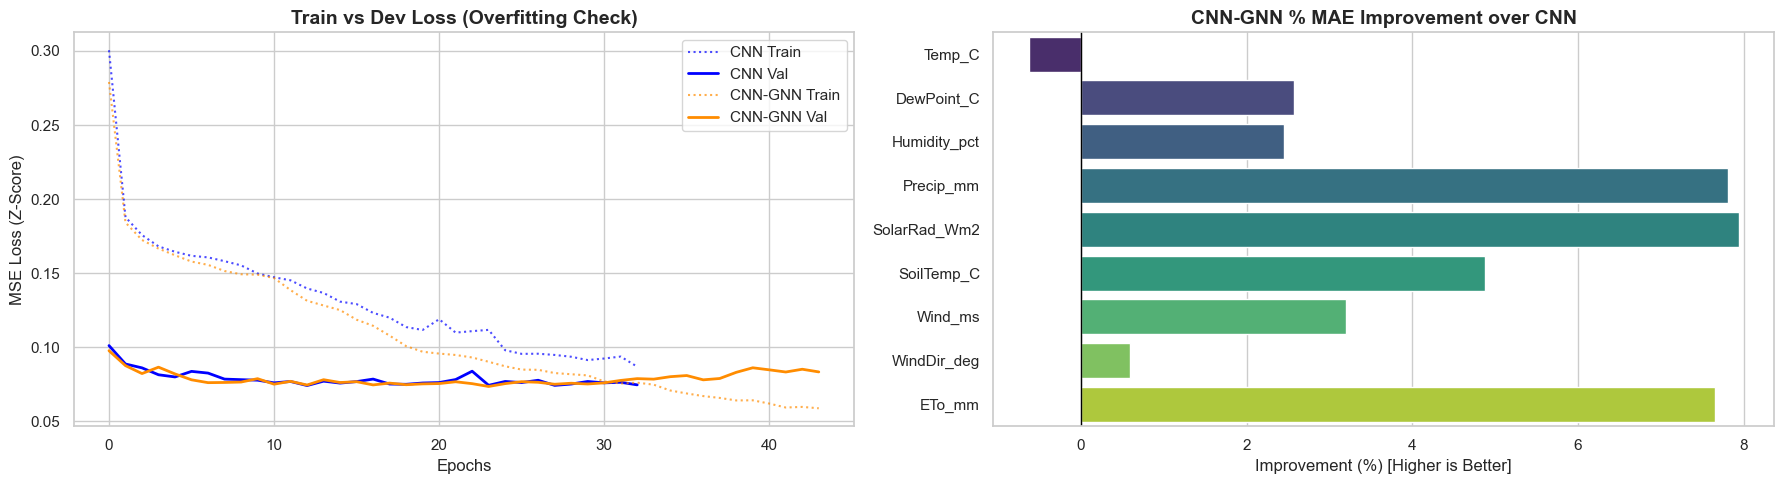

In [20]:
# --- VISUALIZATIONS ---
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Train vs Validation Loss Curves (Overfitting Check)
axes[0].plot(cnn_history['train'], label='CNN Train', linestyle=':', color='blue', alpha=0.7)
axes[0].plot(cnn_history['val'], label='CNN Val', linestyle='-', color='blue', linewidth=2)

axes[0].plot(gnn_history['train'], label='CNN-GNN Train', linestyle=':', color='darkorange', alpha=0.7)
axes[0].plot(gnn_history['val'], label='CNN-GNN Val', linestyle='-', color='darkorange', linewidth=2)

axes[0].set_title('Train vs Dev Loss (Overfitting Check)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss (Z-Score)')
axes[0].legend()

# 2. Bar Chart of Improvement
bar_data = pd.melt(results_df, id_vars=['Variable'], value_vars=['CNN_MAE', 'GNN_MAE'], 
                   var_name='Model', value_name='MAE')

sns.barplot(data=results_df, x='MAE_Improv_%', y='Variable', ax=axes[1], palette='viridis')
axes[1].set_title('CNN-GNN % MAE Improvement over CNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Improvement (%) [Higher is Better]')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

In [23]:
# --- PERSISTENCE (NAIVE) BASELINE ---
per_var_mae_naive = torch.zeros(9).to(device)
per_var_rmse_sum_naive = torch.zeros(9).to(device)
ss_res_naive = torch.zeros(9).to(device)
ss_tot_naive = torch.zeros(9).to(device)
total_samples_naive = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        preds_real_naive = x_batch[:, :, :, -1] 
        
        per_var_mae_naive += torch.abs(preds_real_naive - y_batch).sum(dim=[0, 1])
        per_var_rmse_sum_naive += torch.square(preds_real_naive - y_batch).sum(dim=[0, 1])
        ss_res_naive += torch.square(preds_real_naive - y_batch).sum(dim=[0, 1])
        ss_tot_naive += torch.square(y_batch - means_t).sum(dim=[0, 1])
        
        total_samples_naive += x_batch.size(0) * 41

naive_mae = (per_var_mae_naive / total_samples_naive).cpu().numpy()
naive_rmse = torch.sqrt(per_var_rmse_sum_naive / total_samples_naive).cpu().numpy()
naive_r2 = (1 - ss_res_naive / ss_tot_naive).cpu().numpy()

# Insert new metrics into the DataFrame
if 'Naive_MAE' not in results_df.columns:
    results_df.insert(1, 'Naive_MAE', naive_mae)
if 'Naive_R2' not in results_df.columns:
    results_df.insert(2, 'Naive_R2', naive_r2)

# Handle column naming mismatch if user didn't rerun cell 8
gnn_mae_col = 'GNN_MAE' if 'GNN_MAE' in results_df.columns else 'CNN_GNN_MAE'
gnn_r2_col = 'GNN_R2' if 'GNN_R2' in results_df.columns else 'CNN_GNN_R2'

# MAE Improvement (Lower error is better, so Naive - CNN)
mae_improvement = (results_df['Naive_MAE'] - results_df['CNN_MAE'])
results_df['CNN_beats_Naive_MAE_%'] = (mae_improvement / results_df['Naive_MAE']) * 100

# R² Improvement (Higher score is better, so CNN - Naive)
# IMPORTANT: We use .abs() on the denominator to maintain correct signs if Naive_R2 is negative
r2_improvement = (results_df['CNN_R2'] - results_df['Naive_R2'])
results_df['CNN_beats_Naive_R2_%'] = (r2_improvement / results_df['Naive_R2'].abs()) * 100

print("🎯 PERSISTENCE BASELINE COMPARISON (MAE & R²)")
print("="*125)
columns_to_print = [
    'Variable', 
    'Naive_MAE', 'CNN_MAE', gnn_mae_col, 'CNN_beats_Naive_MAE_%', 
    'Naive_R2', 'CNN_R2', gnn_r2_col, 'CNN_beats_Naive_R2_%'
]
print(results_df[columns_to_print].to_string(index=False, float_format="{:.4f}".format))
print("="*125)

🎯 PERSISTENCE BASELINE COMPARISON (MAE & R²)
    Variable  Naive_MAE  CNN_MAE  GNN_MAE  CNN_beats_Naive_MAE_%  Naive_R2  CNN_R2  GNN_R2  CNN_beats_Naive_R2_%
      Temp_C     1.1920   0.5703   0.5739                52.1520    0.9478  0.9873  0.9872                4.1759
  DewPoint_C     0.5326   0.5290   0.5154                 0.6678    0.9648  0.9691  0.9701                0.4536
Humidity_pct     4.0405   2.4857   2.4248                38.4801    0.9328  0.9734  0.9745                4.3594
   Precip_mm     0.0089   0.0140   0.0129               -56.4594   -0.8205  0.2937  0.2443              135.7921
SolarRad_Wm2    80.2041  26.5255  24.4198                66.9275    0.8992  0.9868  0.9877                9.7397
  SoilTemp_C     0.2023   0.2862   0.2723               -41.4613    0.9940  0.9910  0.9914               -0.3033
     Wind_ms     0.3466   0.3194   0.3091                 7.8481    0.8718  0.8939  0.9003                2.5296
 WindDir_deg    33.5248  36.5329  36.3162          